# MAST-U kinetic reconstruction testing

Set the path to the EFIT file and pick a time-slice to analyse:

In [1]:
efit_path = "/home/chris/astora-mastu/dev/epm044862.nc"
ayc_path = "/home/chris/astora-mastu/dev/ayc044862.nc"
time_index = 100

### Basis set-up

Here we load our stored mesh for modelling the toroidal plasma current density, and use `HexaconeBasis` to create a set of hexagonal-base pyramid basis functions, with one placed at each mesh vertex. This combination of basis functions generates a piecewise-linear representation of the plasma current density over the mesh.

In [2]:
from astora.mesh.basis import HexaconeBasis, BasisInfo

basis_info = BasisInfo.load("hexbasis_6cm.npz")

hex_basis = HexaconeBasis(
    R=basis_info.R,
    z=basis_info.z,
    resolution=basis_info.resolution,
    refinement_level=basis_info.refinement_level
)

## Poloidal field-coil set-up

In [3]:
from astora.diagnostics.magnetics.coils import CoilSet
from mastora.diagnostics.magnetics.coils import get_mastu_coils

coil_dict = get_mastu_coils()
mastu_coil_set = CoilSet(coils = [coil for coil in coil_dict.values()])

## Field probe set-up

In [4]:
from astora.diagnostics.magnetics.models import FieldSensorModel
from mastora.diagnostics.magnetics.probes import get_probe_data

probe_specs, probe_data = get_probe_data(filepath=efit_path)

field_probes_model = FieldSensorModel(
    field_sensor_specs=probe_specs,
    basis=hex_basis,
    coil_set=mastu_coil_set
)

In [5]:
from midas.likelihoods import GaussianLikelihood

probe_timeslice = probe_data.get_slice(time_index=time_index)

probe_likelihood_func = GaussianLikelihood(
    y_data=probe_timeslice.measurements,
    sigma=probe_timeslice.uncertainties,
)

In [6]:
from midas import Diagnostic

probes_diagnostic = Diagnostic(
    diagnostic_model=field_probes_model,
    likelihood=probe_likelihood_func,
    name="field_probes"
)

## Plasma current set-up

In [7]:
from astora.diagnostics.magnetics.models import PlasmaCurrentModel

plasma_current_model = PlasmaCurrentModel(basis=hex_basis)

In [8]:
from mastora.diagnostics.magnetics.current import get_plasma_current_data

plasma_current_data = get_plasma_current_data(filepath=efit_path)
plasma_current_timeslice = plasma_current_data.get_slice(time_index=time_index)

plasma_current_likelihood_func = GaussianLikelihood(
    y_data=plasma_current_timeslice.measurements,
    sigma=plasma_current_timeslice.uncertainties,
)

In [9]:
plasma_current_diagnostic = Diagnostic(
    diagnostic_model=plasma_current_model,
    likelihood=plasma_current_likelihood_func,
    name="plasma_current"
)

## Flux-loop set-up

In [10]:
from astora.diagnostics.magnetics.models import FluxloopModel
from mastora.diagnostics.magnetics.fluxloops import get_fluxloop_data

fluxloop_specs, fluxloop_data = get_fluxloop_data(filepath=efit_path)

fluxloop_model = FluxloopModel(
    fluxloop_specs=fluxloop_specs,
    basis=hex_basis,
    coil_set=mastu_coil_set
)

In [11]:
fluxloop_timeslice = fluxloop_data.get_slice(time_index=time_index)

fluxloop_likelihood_func = GaussianLikelihood(
    y_data=fluxloop_timeslice.measurements,
    sigma=fluxloop_timeslice.uncertainties,
)

In [12]:
fluxloop_diagnostic = Diagnostic(
    diagnostic_model=fluxloop_model,
    likelihood=fluxloop_likelihood_func,
    name="fluxloops"
)

## Pressure set-up

In [ ]:
from numpy import isfinite
from mastora.data import get_traces

pe_data = get_traces(
    group="/ayc/", traces=["r", "p_e", "dp_e"], filepath=ayc_path
)

pressure_radius = pe_data["r"].data[time_index, :]
pressure = pe_data["p_e"].data[time_index, :] * 2.0
finite_data = isfinite(pressure) & (pressure_radius < 1.45)

pressure_radius = pressure_radius[finite_data]
pressure = pressure[finite_data]
pressure_sigma = abs(pressure) * 0.05 + pressure.mean() * 0.03

In [81]:
from astora.diagnostics.pressure.models import ChebyshevRadialPressure


radial_pressure_model = ChebyshevRadialPressure(
    R=pressure_radius,
    z=0.0,
    basis=hex_basis,
    coil_set=mastu_coil_set,
    polynomial_order=32,
)

In [82]:
radial_pressure_likelihood_func = GaussianLikelihood(
    y_data=pressure,
    sigma=pressure_sigma,
)

In [83]:
pressure_diagnostic = Diagnostic(
    name="radial_pressure",
    likelihood=radial_pressure_likelihood_func,
    diagnostic_model=radial_pressure_model,
)

## Priors set-up

### Poloidal field-coil current prior
As the poloidal field coil currents are free parameters, we apply a Gaussian prior to them so they are constrained by the measured values of the coil currents:

In [84]:
from numpy import array

from midas.parameters import ParameterVector
from midas.priors import GaussianPrior
from mastora.diagnostics.magnetics.coils import get_coil_current_data


pf_data = get_coil_current_data(filepath=efit_path).get_slice(time_index=time_index)

pf_currents_prior = GaussianPrior(
    name="pf_currents_prior",
    mean=pf_data.measurements,
    standard_deviation=pf_data.uncertainties,
    parameter_vector=ParameterVector(name="coil_currents", size=pf_data.measurements.size)
)

# set up bounds on the PF current parameters for use in optimization
pf_bounds_width = 6 * pf_data.uncertainties
pf_bounds_width[pf_bounds_width < 1000.] = 1000.
pf_current_bounds = array([
    pf_data.measurements - pf_bounds_width,
    pf_data.measurements + pf_bounds_width
]).T

### Equilibrium current prior

The `EquilibriumCurrentPrior` calculates the difference between the $J_\phi$ values from the free parameters, and the Grad-Shafronov prediction of the equilibrium $J_\phi$, and places a zero-mean gaussian prior on those differences to minimise their value.

In [113]:
from astora.equilibrium import EquilibriumCurrentPrior

equilibrium_current_prior = EquilibriumCurrentPrior(
    name="equilibrium_current",
    basis=hex_basis,
    coil_set=mastu_coil_set,
    sigma=10000.0
)

## Field-model set up

The analysis set-up requires field models for the $p'$ and $FF'$ flux-functions which can be evaluated at any $(R, z)$ position. The `FluxProfile` field model type enables this:

In [114]:
from astora.flux.transforms import CauchyCDF
from astora.flux import FluxProfile

p_prime_field = FluxProfile(
    field_name="p_prime",
    basis=hex_basis,
    coil_set=mastu_coil_set,
    flux_transform=CauchyCDF(name="flux_transform"),
    n_profile_knots=10
)

FF_prime_field = FluxProfile(
    field_name="FF_prime",
    basis=hex_basis,
    coil_set=mastu_coil_set,
    flux_transform=CauchyCDF(name="flux_transform"),
    n_profile_knots=6
)

The field models need to use the greens functions for $\psi$, but these are expensive to calculate so we load them from file and put them into the models cache:

In [115]:
from midas import FieldRequest
basis_coordinates = {"R": basis_info.R, "z": basis_info.z,}

cached_matrices = (basis_info.coils_psi, basis_info.basis_psi)

p_prime_req = FieldRequest(name="p_prime", coordinates=basis_coordinates)
p_prime_field.matrix_cache[p_prime_req] = cached_matrices

FF_prime_req = FieldRequest(name="FF_prime", coordinates=basis_coordinates)
FF_prime_field.matrix_cache[FF_prime_req] = cached_matrices

## Building the posterior

In [116]:
from midas import build_posterior

posterior = build_posterior(
    diagnostics=[
        probes_diagnostic,
        plasma_current_diagnostic,
        fluxloop_diagnostic,
        pressure_diagnostic,
    ],
    priors=[
        pf_currents_prior,
        equilibrium_current_prior,
    ],
    field_models=[p_prime_field, FF_prime_field],
)

In [117]:
posterior.parameter_sizes

{'FF_prime_spline_values': 6,
 'coil_currents': 33,
 'flux_transform': 2,
 'integration_constant': 1,
 'ln_J': 954,
 'p_prime_spline_values': 10}

## MAP estimation

To make a sensible initial guess for the current distribution, we create a Gaussian-shaped current blob and scale its amplitude to match the total measured plasma current:

In [118]:
from numpy import log, exp, sqrt, linspace


def generate_guess_array(R0, dR, dz, psi0, ln_dpsi, PP_max, FFP_max, shape, p_inboard):
    rho = sqrt(((basis_info.R - R0) / dR)**2 + (basis_info.z / dz)**2)
    ln_J_guess = -abs(rho)**shape
    # scale-up the current distribution to match the measured total plasma current
    guess_current = exp(ln_J_guess).sum() * hex_basis.total_current
    adjust_factor = plasma_current_timeslice.measurements.sum() / guess_current
    ln_J_guess += log(adjust_factor)

    D = {
        "coil_currents": pf_data.measurements,
        "ln_J": ln_J_guess,
        "p_prime_spline_values": linspace(1000., PP_max, p_prime_field.profile_spline.n_knots),
        "flux_transform": (psi0, ln_dpsi),
        "FF_prime_spline_values": linspace(0.01, FFP_max, FF_prime_field.profile_spline.n_knots),
        'integration_constant': p_inboard
    }
    return posterior.merge_parameters(D)


def guess_optimisation(params: ndarray):
    R0, dR, dz, psi0, ln_dpsi, P_max, FFP_max, shape, p_inboard = params
    theta = generate_guess_array(R0, dR, dz, psi0, ln_dpsi, P_max, FFP_max, shape, p_inboard)
    return posterior.cost(theta)

guess_opt_bounds = [
    (0.75, 1.1), (0.1, 0.5), (0.2, 1.0), (-0.2, 0.2), (log(1e-4), log(0.5)), (1e4, 1e6), (0.02, 1.0), (1.5, 4), (100.0, 3000.0)
]

from scipy.optimize import differential_evolution
guess_optimisation_result = differential_evolution(
    func=guess_optimisation,
    bounds=guess_opt_bounds,
    maxiter=20,
    popsize=8,
    polish=True,
    rng=42,
)

# extract the MAP estimate parameters from the results
optimised_guess_params = guess_optimisation_result.x
initial_guess_array = generate_guess_array(*optimised_guess_params)

Set up bounds for the optimisation using `PlasmaState.build_bounds`:

In [119]:
from numpy import clip

bounds_dict = {
    "coil_currents": pf_current_bounds,
    "ln_J": (-1.0, log(1.5e6)),
    "p_prime_spline_values": (0.0, 1e6),
    "flux_transform": array([(-0.2, 0.2), (-4*log(10), 0.0)]),
    "FF_prime_spline_values": (0.0, 1.5),
    "integration_constant": (100.0, 3000.0),
}

bounds = posterior.build_bounds(bounds_dict)

initial_guess_array = clip(initial_guess_array, bounds[:, 0], bounds[:, 1])

Verify the initial guess returns a valid log-probability:

In [120]:
print(f"initial guess log-prob {posterior.log_probability(initial_guess_array):.2f}")

initial guess log-prob -8431.03


Verify that the analytic gradient calculations match finite-difference:

In [121]:
from midas.validation import validate_gradient

grad_report = validate_gradient(
    posterior=posterior,
    parameter_bounds=bounds,
    n_samples=5
)

grad_report.print_report()

Gradient validation: PASS

[field_probes]
	Parameter              | Status | Max direction error | Max magnitude error | Pass rate
	-----------------------+--------+---------------------+---------------------+----------
	FF_prime_spline_values | PASS   |                   0 |                   0 |    100.0%
	coil_currents          | PASS   |            9.58e-10 |            1.15e-10 |    100.0%
	flux_transform         | PASS   |                   0 |                   0 |    100.0%
	integration_constant   | PASS   |                   0 |                   0 |    100.0%
	ln_J                   | PASS   |            1.04e-08 |            5.62e-10 |    100.0%
	p_prime_spline_values  | PASS   |                   0 |                   0 |    100.0%

[plasma_current]
	Parameter              | Status | Max direction error | Max magnitude error | Pass rate
	-----------------------+--------+---------------------+---------------------+----------
	FF_prime_spline_values | PASS   |                

The `NormalisedCost` is a wrapper for the posterior which normalises all parameters to the range $[0, 1]$ based on their bounds, and returns the negative log-posterior probabilty.

In [122]:
from midas.normalisation import NormalisedCost

opt_func = NormalisedCost(
    posterior=posterior,
    bounds=bounds,
)

We can pass the `cost` and `cost_gradient` methods of a `NormalisedCost` instance directly to optimizers to find the MAP estimate:

In [123]:
from scipy.optimize import minimize
from threadpoolctl import threadpool_limits

with threadpool_limits(limits=1, user_api="blas"):
    opt_result = minimize(
        fun=opt_func.cost,
        x0=opt_func.normalise(initial_guess_array),
        method="TNC",
        bounds=opt_func.normalised_bounds,
        jac=opt_func.cost_gradient,
        options={"maxfun": 25000, "ftol": 1e-8, "xtol": 1e-10, "gtol": 1e-7},
    )

# NormalisedCost keeps track of the best parameters
map_estimate_params = opt_func.best_theta

# verify that the MAP parameters yield a higher log-probability than the initial guess
print(f"initial guess log-prob {posterior.log_probability(initial_guess_array):.2f}")
print(f" MAP estimate log-prob {posterior.log_probability(map_estimate_params):.2f}")

initial guess log-prob -8431.03
 MAP estimate log-prob 33.87


In [124]:
print(opt_result)

 message: Max. number of function evaluations reached
 success: False
  status: 3
     fun: -33.86990820241755
       x: [ 5.710e-02  6.317e-02 ...  1.000e+00  0.000e+00]
     nit: 2278
     jac: [ 8.387e+00  2.225e+01 ... -6.357e-01  1.059e-01]
    nfev: 25000


### Data reproduction checks using MAP estimate
We can use `posterior.get_model_predictions` to get the predictions of all the forward-models:


In [125]:
map_predictions = posterior.get_model_predictions(map_estimate_params)
{name for name in map_predictions.keys()}

{'field_probes', 'fluxloops', 'plasma_current', 'radial_pressure'}

Check the agreement of the plasma current:

In [126]:
print(f"measured plasma current: {plasma_current_timeslice.measurements[0]:.2f}")
print(f"inferred plasma current: {map_predictions["plasma_current"]:.2f}")

measured plasma current: 744343.29
inferred plasma current: 737094.72


Check the agreement of the field probes:

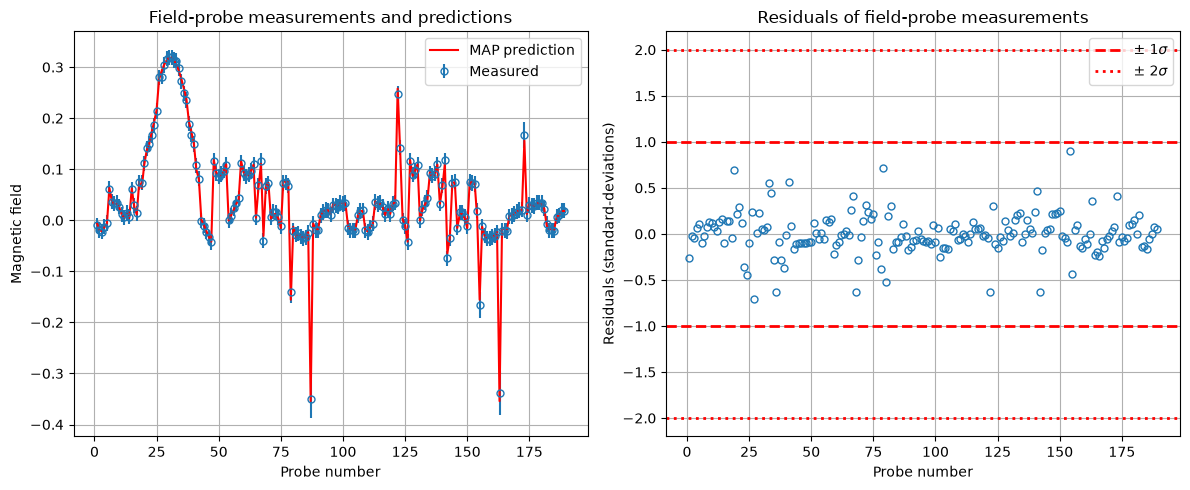

In [127]:
import matplotlib.pyplot as plt
from numpy import arange

probe_number = arange(probe_timeslice.measurements.size) + 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.errorbar(
    probe_number,
    probe_timeslice.measurements,
    yerr=probe_timeslice.uncertainties,
    marker="o",
    ls="none",
    markerfacecolor="none",
    markersize=5,
    label="Measured",
)
ax1.plot(
    probe_number,
    map_predictions["field_probes"],
    label="MAP prediction",
    c="red"
)
ax1.set_xlabel("Probe number")
ax1.set_ylabel("Magnetic field")
ax1.set_title("Field-probe measurements and predictions")
ax1.grid()
ax1.legend()

residuals = (probe_timeslice.measurements - map_predictions["field_probes"]) / probe_timeslice.uncertainties
ax2.plot(
    probe_number,
    residuals,
    marker="o",
    ls="none",
    markerfacecolor="none",
    markersize=5,
)
ax2.axhline(1, lw=2, ls="--", c="red", label=r"$\pm$ 1$\sigma$")
ax2.axhline(-1, lw=2, ls="--", c="red")
ax2.axhline(2, lw=2, ls="dotted", c="red", label=r"$\pm$ 2$\sigma$")
ax2.axhline(-2, lw=2, ls="dotted", c="red")
ax2.set_xlabel("Probe number")
ax2.set_ylabel("Residuals (standard-deviations)")
ax2.set_title("Residuals of field-probe measurements")
ax2.grid()
ax2.legend()

fig.tight_layout()
plt.show()

Check the agreement of the flux-loops

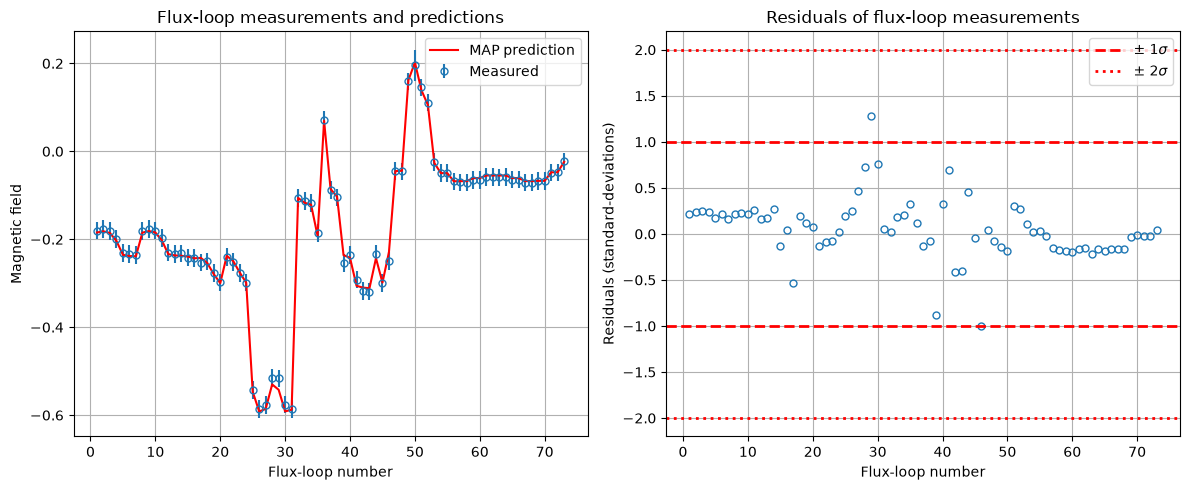

In [128]:
import matplotlib.pyplot as plt
from numpy import arange

probe_number = arange(fluxloop_timeslice.measurements.size) + 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.errorbar(
    probe_number,
    fluxloop_timeslice.measurements,
    yerr=fluxloop_timeslice.uncertainties,
    marker="o",
    ls="none",
    markerfacecolor="none",
    markersize=5,
    label="Measured",
)
ax1.plot(
    probe_number,
    map_predictions["fluxloops"],
    label="MAP prediction",
    c="red"
)
ax1.set_xlabel("Flux-loop number")
ax1.set_ylabel("Magnetic field")
ax1.set_title("Flux-loop measurements and predictions")
ax1.grid()
ax1.legend()

residuals = (fluxloop_timeslice.measurements - map_predictions["fluxloops"]) / fluxloop_timeslice.uncertainties
ax2.plot(
    probe_number,
    residuals,
    marker="o",
    ls="none",
    markerfacecolor="none",
    markersize=5,
)
ax2.axhline(1, lw=2, ls="--", c="red", label=r"$\pm$ 1$\sigma$")
ax2.axhline(-1, lw=2, ls="--", c="red")
ax2.axhline(2, lw=2, ls="dotted", c="red", label=r"$\pm$ 2$\sigma$")
ax2.axhline(-2, lw=2, ls="dotted", c="red")
ax2.set_xlabel("Flux-loop number")
ax2.set_ylabel("Residuals (standard-deviations)")
ax2.set_title("Residuals of flux-loop measurements")
ax2.grid()
ax2.legend()

fig.tight_layout()
plt.show()

Check the agreement with the pressure data:

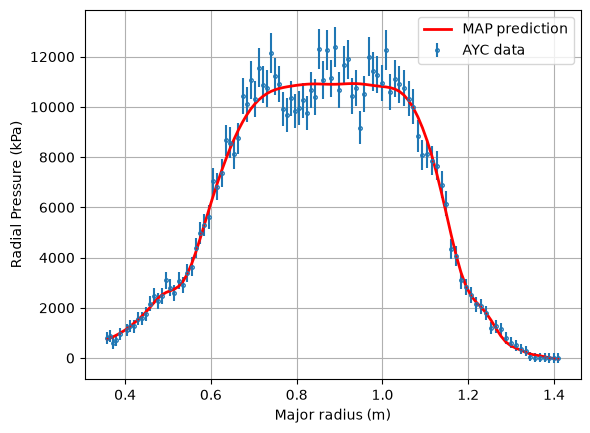

In [129]:
plt.errorbar(
    pressure_radius,
    pressure,
    yerr=pressure_sigma,
    marker=".",
    markerfacecolor="none",
    markersize=5,
    ls="none",
    label="AYC data"
)

plt.plot(
    pressure_radius, map_predictions["radial_pressure"],
    lw=2, c="red", label="MAP prediction"
)
plt.xlabel("Major radius (m)")
plt.ylabel("Radial Pressure (kPa)")
plt.legend()
plt.grid()
plt.show()

### Plot the inferred toroidal current density $J_\phi$

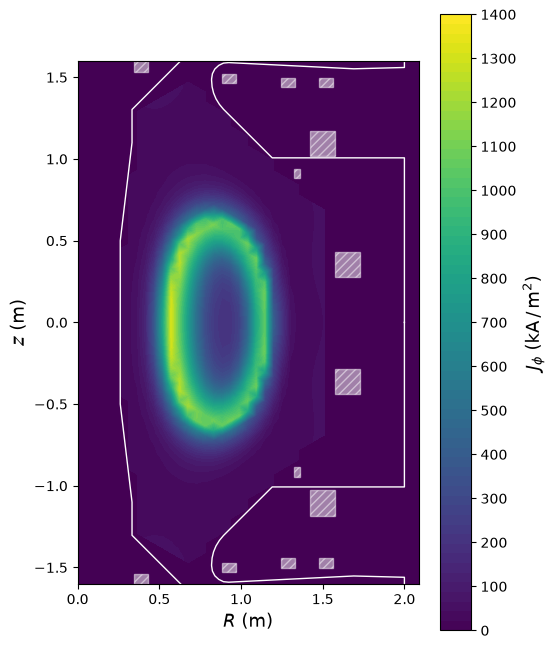

In [130]:
from tokamesh.tokamaks import mastu_boundary
from mastora.diagnostics.magnetics.coils.cases import draw_cases
from numpy import exp, linspace, ceil

map_param_dict = posterior.split_parameters(map_estimate_params)
J_values = exp(map_param_dict["ln_J"])
v = int(ceil(J_values.max() * 1e-3 / 100.0))
color_levels = linspace(0.0, 100 * v, 65)


fig = plt.figure(figsize=(5.5, 8))
ax = fig.add_subplot(1, 1, 1)
ax.set_facecolor(plt.get_cmap("viridis")(0.0))
contours = ax.tricontourf(
    basis_info.R,
    basis_info.z,
    basis_info.triangles,
    J_values * 1e-3,
    levels=color_levels,
    cmap="viridis",
)

cbar = fig.colorbar(contours, ax=ax)
cbar.set_label(r"$J_{\phi}$ $\mathrm{(kA \,/\, m^2)}$", fontsize=13)
cbar.set_ticks(linspace(0, 100 * v, v + 1))

ax.plot(*mastu_boundary(), lw=1, color="white")
draw_cases(ax, fill_color="white")
ax.set_aspect("equal")
ax.set_xlim([0, None])

ax.set_ylim([-1.6, 1.6])
ax.set_xlabel(r"$R$ (m)", fontsize=13)
ax.set_ylabel(r"$z$ (m)", fontsize=13)
plt.show()

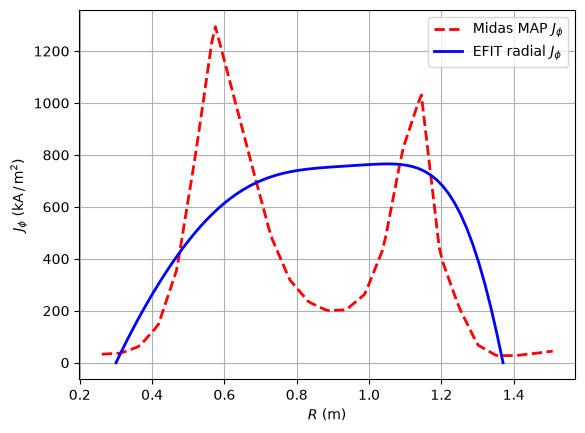

In [131]:
from numpy import linspace, zeros

group = "/epm/output/radialProfiles/"
traces = ["r", "jphi"]
j_data = get_traces(group=group, traces=traces, filepath=efit_path)

radial_jphi = j_data["jphi"].data[time_index, :]
profile_radius = j_data["r"].data[time_index, :]

R_interp = linspace(basis_info.R.min(), basis_info.R.max(), 128)
matrix = hex_basis.get_interpolator_matrix(R=R_interp, z=zeros(128))

midplane_J = J_values @ matrix.T


fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(R_interp, midplane_J * 1e-3, c="red", ls="--", lw=2, label=r"Midas MAP $J_\phi$")
ax.plot(profile_radius, radial_jphi * 1e-3, lw=2, color="blue", label=r"EFIT radial $J_\phi$")
ax.set_ylabel(r"$J_\phi$ $\mathrm{(kA\,/\,m^2)}$")
ax.set_xlabel(r"$R$ $\mathrm{(m)}$")
ax.legend()
ax.grid()
plt.show()

### Calculate $\psi(R, z)$

Build a mesh on which to evaluate $\psi$:

In [132]:
from numpy import linspace, meshgrid
n = 64
R_axis = linspace(0.0, 2.1, n)
z_axis = linspace(-2.2, 2.2, 2*n)
R_mesh, z_mesh = meshgrid(R_axis, z_axis, indexing='ij')

Get the $\psi$ contribution from the PF coils:

In [133]:
pf_psi = mastu_coil_set.psi(currents=pf_data.measurements, R=R_mesh.flatten(), z=z_mesh.flatten())
pf_psi = pf_psi.reshape(R_mesh.shape)

Get the $\psi$ contribution from the plasma current and calcualte the total $\psi$:

In [134]:
from numpy import load
psi_data = load("hex_basis_psi_matrix.npz")

plasma_psi = psi_data["hex_basis_psi_matrix"] @ J_values
plasma_psi = plasma_psi.reshape(R_mesh.shape)

psi = pf_psi + plasma_psi

Use the `NormalisedPoloidalFlux` tool from `astora` to get $\psi_N$:

In [135]:
from astora.tools import NormalisedPoloidalFlux
from tokamesh.construction import Polygon
boundary_polygon = Polygon(*mastu_boundary()) 

psi = pf_psi + plasma_psi
PsiNorm = NormalisedPoloidalFlux(R=R_axis, z=z_axis, psi=psi, boundary=boundary_polygon)

In [136]:
group = "/epm/output/profiles2D/"
traces = ["r", "z", "poloidalFlux"]
efit_psi_data = get_traces(group=group, traces=traces, filepath=efit_path)

efit_psi_r = efit_psi_data["r"].data
efit_psi_z = efit_psi_data["z"].data
efit_psi = efit_psi_data["poloidalFlux"].data[time_index, :, :]

efit_PsiNorm = NormalisedPoloidalFlux(R=efit_psi_r, z=efit_psi_z, psi=efit_psi, boundary=boundary_polygon)

Plot $\psi_N$ and the separatrix:

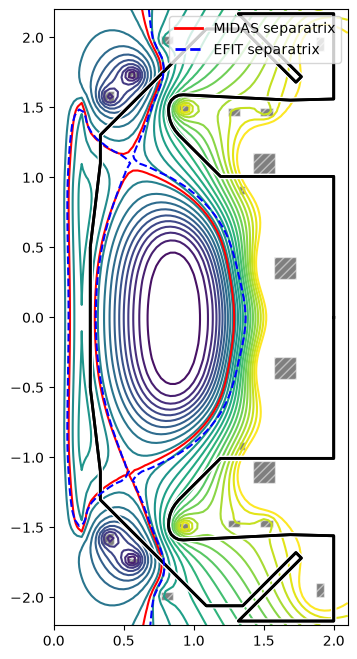

In [137]:
fig = plt.figure(figsize=(4.5, 8.0))
ax = fig.add_subplot(1, 1, 1)

PsiNorm.plot_equilibrium(axis=ax, flux_range=(0.0, 2.2))
ax.plot(*mastu_boundary(), lw=2, color="black")
draw_cases(ax, fill_color="black")

ax.contour(
    efit_PsiNorm.R,
    efit_PsiNorm.z,
    efit_PsiNorm.psi_grid.T,
    levels=[1.0],
    colors=["blue"],
    linestyles=["dashed"],
)
plt.plot([-1, -1], [-1, -1], lw=2, color="red", label="MIDAS separatrix")
plt.plot([-1, -1], [-1, -1], lw=2, color="blue", label="EFIT separatrix", ls="--")
ax.legend(loc="upper right")
plt.show()

In [138]:
R_axis = linspace(1.2, 1.5, 1500)

print(
    f"""
    MIDAS midplane separatrix: {R_axis[abs(PsiNorm.psi_spline(R_axis, 0.0) - 1.0).argmin()]:.4f}m
     EFIT midplane separatrix: {R_axis[abs(efit_PsiNorm.psi_spline(R_axis, 0.0) - 1.0).argmin()]:.4f}m
    """
)


    MIDAS midplane separatrix: 1.2889m
     EFIT midplane separatrix: 1.3705m
    


## Equilibrium condition check

Find the difference between the $J_\phi$ parameter values and the prediction of the equilibrium $J_\phi$ at each mesh vertex:

In [139]:
from midas import FieldRequest

map_param_dict = posterior.split_parameters(map_estimate_params)
J_values = exp(map_param_dict["ln_J"])
basis_coordinates = {"R": hex_basis.R_basis, "z": hex_basis.z_basis,}

p_prime = posterior.get_field_values(
    theta=map_estimate_params,
    field_request=FieldRequest(name="p_prime", coordinates=basis_coordinates)
)

FF_prime = posterior.get_field_values(
    theta=map_estimate_params,
    field_request=FieldRequest(name="FF_prime", coordinates=basis_coordinates)
)

J_eq = equilibrium_current_prior.equilibrium_currents(
    p_prime=p_prime,
    FF_prime=FF_prime
)

J_diff = J_values - J_eq

eq_stats = f"""
[ Equilibrium condition statistics ]
        Maximum absolute current difference: {abs(J_diff).max():.2f} (A / m^2)
           Mean absolute current difference: {abs(J_diff).mean():.2f} (A / m^2)
Mean absolute percentage current difference: {abs((J_values / J_eq - 1)).mean() * 100:.2f} (%)
"""
print(eq_stats)


[ Equilibrium condition statistics ]
        Maximum absolute current difference: 386.84 (A / m^2)
           Mean absolute current difference: 46.73 (A / m^2)
Mean absolute percentage current difference: 0.06 (%)



Now plot the current density differences on the mesh:

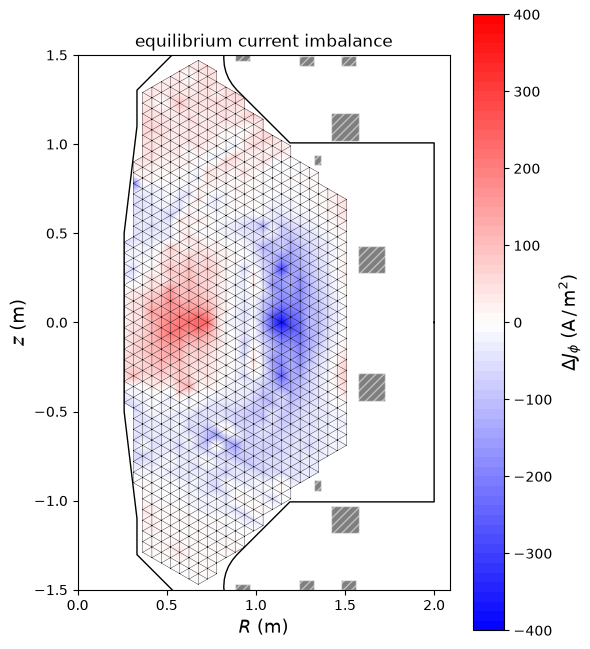

In [141]:
fig = plt.figure(figsize=(6, 8))
ax = fig.add_subplot(1, 1, 1)

J_limit = 400.0
contours = ax.tricontourf(
    basis_info.R,
    basis_info.z,
    basis_info.triangles,
    J_diff,
    levels=linspace(-J_limit, J_limit, 65),
    cmap="bwr",
)

cbar = fig.colorbar(contours, ax=ax)
cbar.set_label(r"$\Delta J_{\phi}$ $\mathrm{(A \,/\, m^2)}$", fontsize=13)
cbar.set_ticks(linspace(-J_limit, J_limit, 9))

ax.triplot(basis_info.R, basis_info.z, basis_info.triangles, color="black", lw=0.25)
ax.plot(*mastu_boundary(), lw=1, color="black")
draw_cases(ax, fill_color="black")
ax.set_aspect("equal")
ax.set_xlim([0, None])
ax.set_ylim([-1.5, 1.5])
ax.set_xlabel(r"$R$ (m)", fontsize=13)
ax.set_ylabel(r"$z$ (m)", fontsize=13)
ax.set_title("equilibrium current imbalance")
plt.show()